In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [4]:
# Load the dataset
df = pd.read_csv('Electric Vehicle Sales by State in India.csv')

In [5]:
print(df.head())

     Year Month_Name      Date           State         Vehicle_Class  \
0  2014.0        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014.0        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014.0        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014.0        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014.0        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                0.0  
1           Others       Others                0.0  
2           Others       Others                0.0  
3           Others       Others                0.0  
4              Bus          Bus                0.0  


In [6]:
# Checking information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB
None


In [7]:
# Check if there are any missing (null) values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [8]:
# Let's check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [9]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [10]:
# If 'Year' column is float, convert it to integer
if df['Year'].dtype == 'float64':
    df['Year'] = df['Year'].astype(int)

In [11]:
# Convert categorical columns to 'category' dtype to save memory
categorical_columns = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
df[categorical_columns] = df[categorical_columns].astype('category')

In [12]:
# Verify changes
print("\nUpdated Dataset Info:\n")
print(df.info())


Updated Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  int32         
 1   Month_Name         96845 non-null  category      
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  category      
 4   Vehicle_Class      96845 non-null  category      
 5   Vehicle_Category   96845 non-null  category      
 6   Vehicle_Type       96845 non-null  category      
 7   EV_Sales_Quantity  96845 non-null  float64       
dtypes: category(5), datetime64[ns](1), float64(1), int32(1)
memory usage: 2.3 MB
None


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

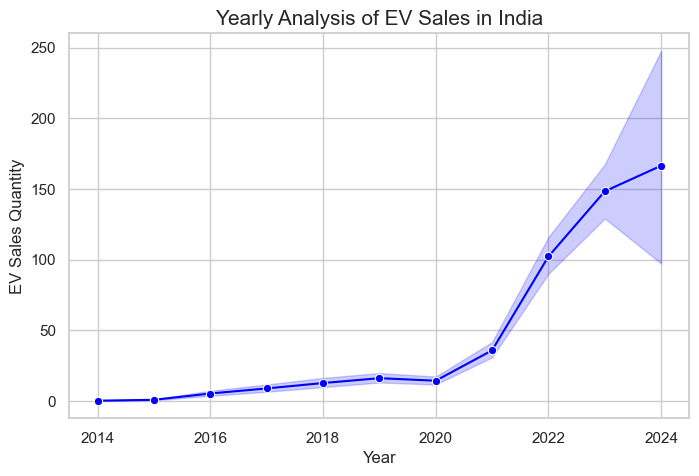

In [14]:
# EV Sales Over the Years
plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df, marker='o', color='blue')
plt.title('Yearly Analysis of EV Sales in India', fontsize=15)
plt.xlabel('Year')
plt.ylabel('EV Sales Quantity')
plt.show()

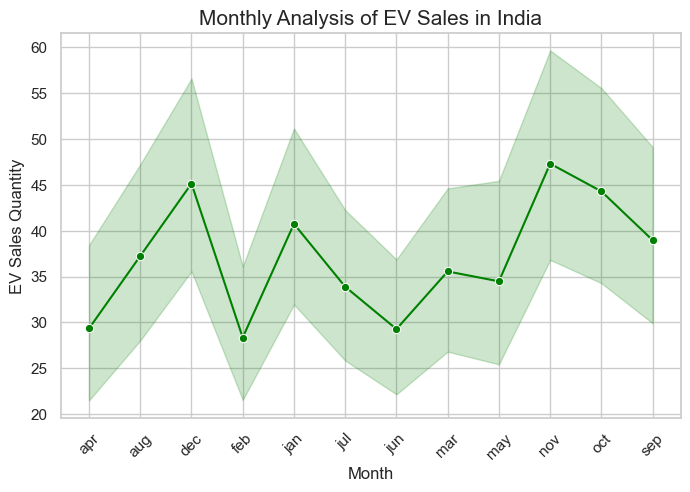

In [15]:
# EV Sales Month-wise
plt.figure(figsize=(8,5))
sns.lineplot(x='Month_Name', y='EV_Sales_Quantity', data=df, marker='o', color='green')
plt.title('Monthly Analysis of EV Sales in India', fontsize=15)
plt.xlabel('Month')
plt.ylabel('EV Sales Quantity')
plt.xticks(rotation=45)
plt.show()


C:\Users\ACER\AppData\Local\Temp\ipykernel_2184\737737998.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
C:\Users\ACER\AppData\Local\Temp\ipykernel_2184\737737998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette='viridis')


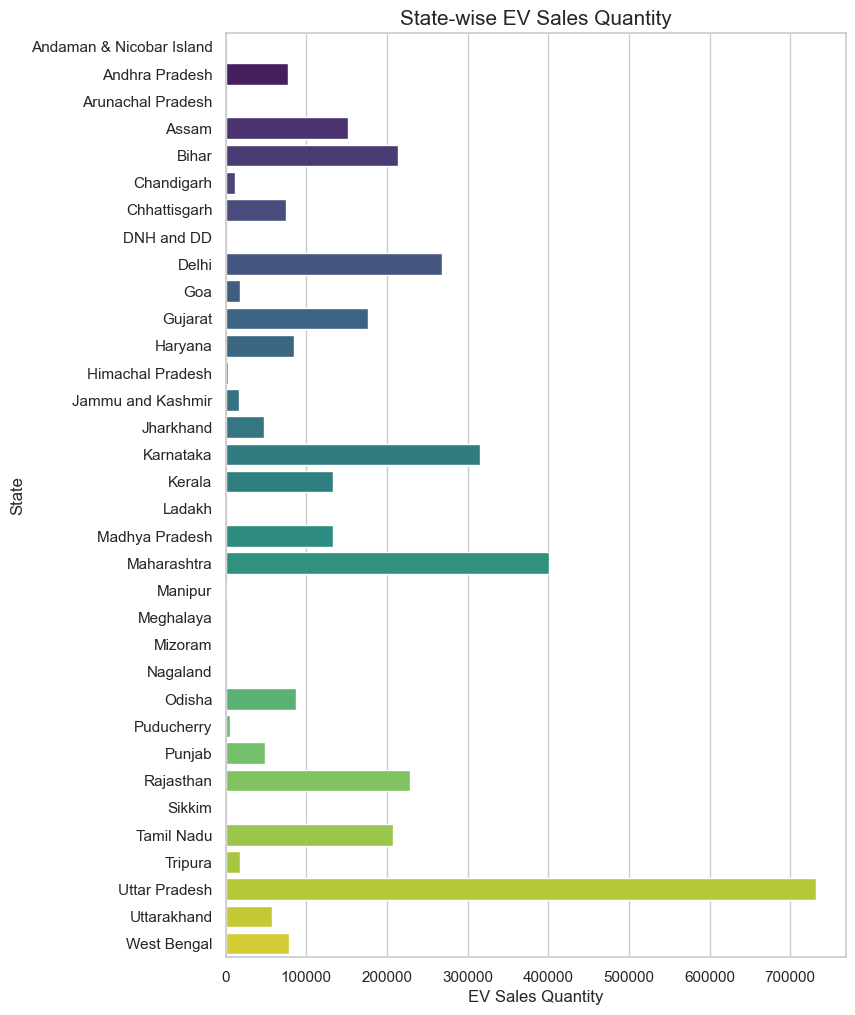

In [16]:
# State-Wise EV Sales
plt.figure(figsize=(8,12))
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=state_sales.values, y=state_sales.index, palette='viridis')
plt.title('State-wise EV Sales Quantity', fontsize=15)
plt.xlabel('EV Sales Quantity')
plt.ylabel('State')
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_2184\2144321640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_states = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)
C:\Users\ACER\AppData\Local\Temp\ipykernel_2184\2144321640.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')


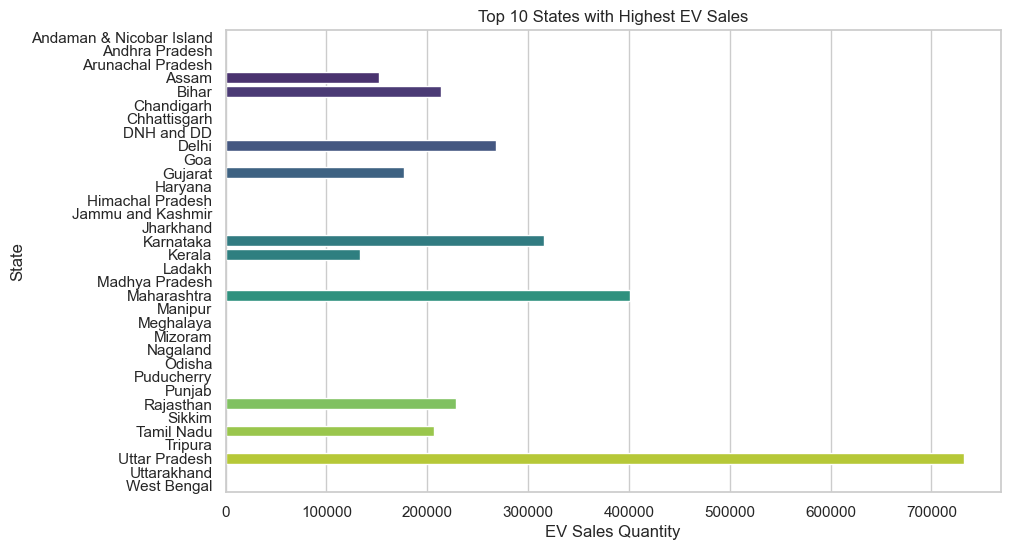

In [17]:
# Top 10 States with Highest EV Sales
top_states = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')
plt.title('Top 10 States with Highest EV Sales')
plt.xlabel('EV Sales Quantity')
plt.ylabel('State')
plt.show()

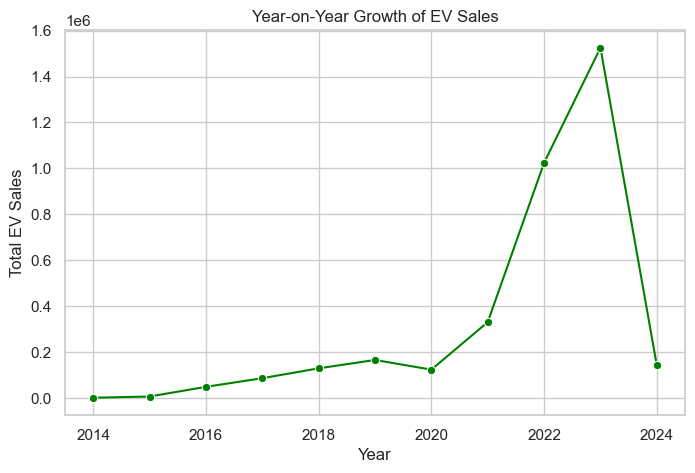

In [36]:
# EV Sales Growth Year-on-Year
yearly_sales = df.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=yearly_sales, marker='o', color='green')
plt.title('Year-on-Year Growth of EV Sales')
plt.xlabel('Year')
plt.ylabel('Total EV Sales')
plt.grid(True)
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_2184\2872231712.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_trend = df.groupby(['Year', 'Vehicle_Category'])['EV_Sales_Quantity'].sum().reset_index()


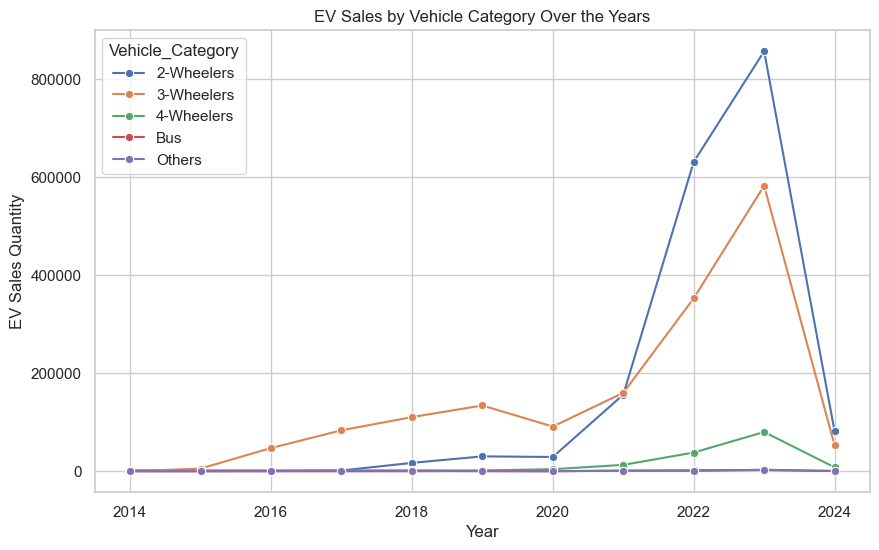

In [40]:
# EV Sales by Vehicle Category Over the Years
category_trend = df.groupby(['Year', 'Vehicle_Category'])['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=category_trend, x='Year', y='EV_Sales_Quantity', hue='Vehicle_Category', marker='o')
plt.title('EV Sales by Vehicle Category Over the Years')
plt.xlabel('Year')
plt.ylabel('EV Sales Quantity')
plt.grid(True)
plt.show()

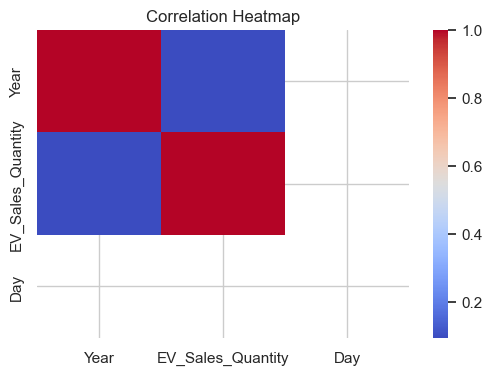

In [106]:
# Correlation Heatmap (Numerical Columns Only)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()